In [1]:
!pip install -q duckdb pandas matplotlib seaborn datasets fsspec==2026.3.0 s3fs==2026.3.0 huggingface_hub --upgrade

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from huggingface_hub import snapshot_download

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

REPO_ID   = "chuongdo1104/amazon-2023-silver"
LOCAL_DIR = "./amazon-2023-silver"

GROUP_ORDER  = ["HEAD", "MID", "TAIL", "COLD_START"]
GROUP_COLORS = {"HEAD": "#e07b54", "MID": "#f4c430", "TAIL": "#3bba74", "COLD_START": "#5b8db8"}

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — TẢI DỮ LIỆU TỪ HUGGING FACE + ĐĂNG KÝ DUCKDB VIEWS
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("SECTION 1 — TẢI DỮ LIỆU TỪ HUGGING FACE")
print("=" * 60)

print(f"📥 Đang tải snapshot từ: {REPO_ID}")
snapshot_download(repo_id=REPO_ID, repo_type="dataset", local_dir=LOCAL_DIR)
print(f"✅ Đã tải xong → {LOCAL_DIR}")

con = duckdb.connect(database=":memory:")

views = {
    "interactions_train" : f"{LOCAL_DIR}/silver/silver_interactions_train.parquet/**/*.parquet",
    "interactions_val"   : f"{LOCAL_DIR}/silver/silver_interactions_val.parquet/**/*.parquet",
    "item_popularity"    : f"{LOCAL_DIR}/silver/silver_item_popularity.parquet/**/*.parquet",
    "item_text"          : f"{LOCAL_DIR}/silver/silver_item_text_profile.parquet/**/*.parquet",
    "user_text"          : f"{LOCAL_DIR}/silver/silver_user_text_profile.parquet/**/*.parquet",
    "val_ground_truth"   : f"{LOCAL_DIR}/silver/silver_val_ground_truth.parquet/**/*.parquet",
}

print("\n🔧 Đăng ký DuckDB Views...")
for view_name, path in views.items():
    try:
        con.execute(
            f"CREATE VIEW {view_name} AS "
            f"SELECT * FROM read_parquet('{path}', hive_partitioning=1)"
        )
        cnt = con.execute(f"SELECT COUNT(*) FROM {view_name}").df().iloc[0, 0]
        cols = con.execute(f"DESCRIBE {view_name}").df()["column_name"].tolist()
        print(f"  ✅ {view_name:<22}: {cnt:>12,} rows | {cols}")
    except Exception as e:
        print(f"  ❌ Lỗi load view {view_name}: {e}")


SECTION 1 — TẢI DỮ LIỆU TỪ HUGGING FACE
📥 Đang tải snapshot từ: chuongdo1104/amazon-2023-silver


Fetching 67 files:   0%|          | 0/67 [00:00<?, ?it/s]

✅ Đã tải xong → ./amazon-2023-silver

🔧 Đăng ký DuckDB Views...
  ✅ interactions_train    :   11,123,425 rows | ['parent_asin', 'reviewer_id', 'rating', 'timestamp', 'helpful_vote', 'train_freq', 'popularity_group', 'edge_weight', 'year_month']
  ✅ interactions_val      :    1,483,920 rows | ['parent_asin', 'reviewer_id', 'rating', 'timestamp', 'helpful_vote', 'train_freq', 'popularity_group', 'edge_weight', 'year_month']
  ✅ item_popularity       :      922,459 rows | ['parent_asin', 'train_freq', 'popularity_group']
  ✅ item_text             :    1,610,012 rows | ['parent_asin', 'title', 'main_category', 'item_text', 'text_source_level', 'token_estimate', 'average_rating', 'rating_number', 'train_freq', 'popularity_group']
  ✅ user_text             :    1,483,919 rows | ['reviewer_id', 'user_text', 'review_count_train', 'avg_rating', 'avg_review_weight']
  ✅ val_ground_truth      :    1,483,920 rows | ['parent_asin', 'reviewer_id', 'timestamp', 'rating', 'popularity_group', 'train_fr


SECTION 2 — ITEM POPULARITY DISTRIBUTION

[Train Items] Popularity Group:
  HEAD        :    194,124 (21.0%)
  MID         :     84,077 (9.1%)
  TAIL        :    644,258 (69.8%)
  COLD_START  :          0 (0.0%)

[All Items incl. Cold-Start] Popularity Group:
  HEAD        :    194,124 (12.1%)
  MID         :     84,077 (5.2%)
  TAIL        :    644,258 (40.0%)
  COLD_START  :    687,553 (42.7%)


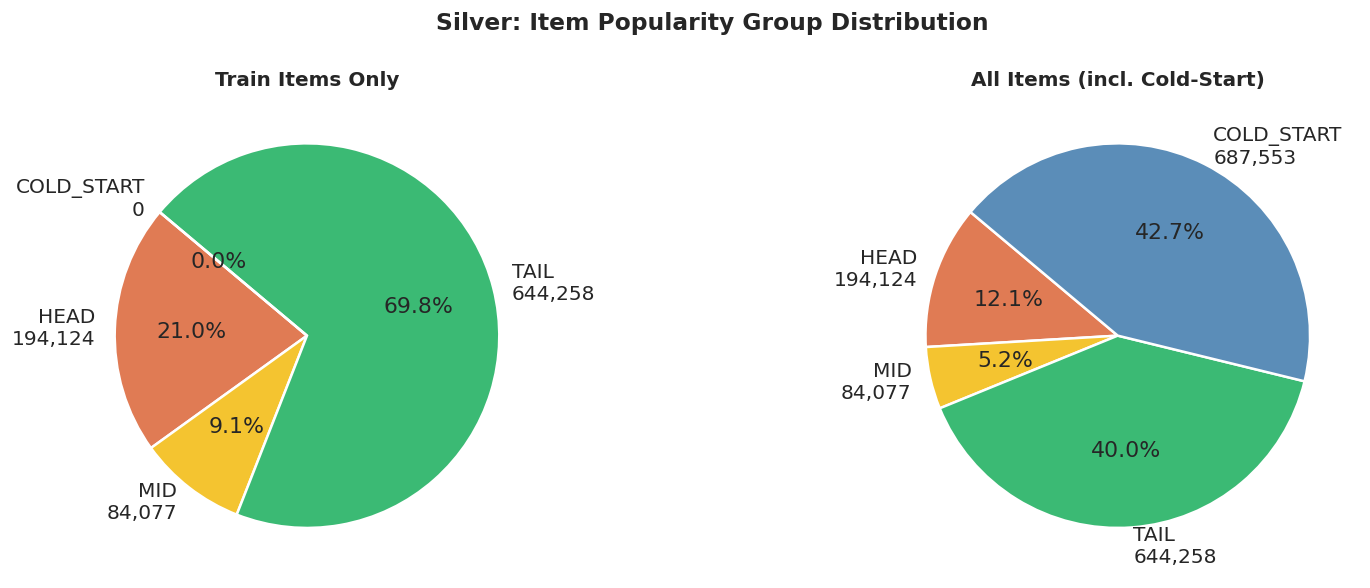

📊 Saved: eda_silver_popularity_pie.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ITEM POPULARITY DISTRIBUTION (HEAD/MID/TAIL/COLD_START)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 2 — ITEM POPULARITY DISTRIBUTION")
print("="*60)

# Train items (từ item_popularity)
pop_train = con.execute("""
    SELECT popularity_group, COUNT(*) AS cnt
    FROM item_popularity
    GROUP BY popularity_group
""").df().set_index("popularity_group")["cnt"]

# All items incl. cold-start (từ item_text)
pop_all = con.execute("""
    SELECT popularity_group, COUNT(*) AS cnt
    FROM item_text
    GROUP BY popularity_group
""").df().set_index("popularity_group")["cnt"]

n_train_total = pop_train.sum()
n_all_total   = pop_all.sum()

print("\n[Train Items] Popularity Group:")
for g in GROUP_ORDER:
    cnt = pop_train.get(g, 0)
    print(f"  {g:<12}: {cnt:>10,} ({cnt/max(n_train_total,1)*100:.1f}%)")

print("\n[All Items incl. Cold-Start] Popularity Group:")
for g in GROUP_ORDER:
    cnt = pop_all.get(g, 0)
    print(f"  {g:<12}: {cnt:>10,} ({cnt/max(n_all_total,1)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, pop_series, total) in zip(axes, [
    ("Train Items Only", pop_train, n_train_total),
    ("All Items (incl. Cold-Start)", pop_all, n_all_total),
]):
    data = [pop_series.get(g, 0) for g in GROUP_ORDER]
    labels = [f"{g}\n{v:,}" for g, v in zip(GROUP_ORDER, data)]
    colors = [GROUP_COLORS[g] for g in GROUP_ORDER]
    ax.pie(data, labels=labels, colors=colors, autopct="%1.1f%%",
           startangle=140, wedgeprops=dict(edgecolor="white", linewidth=1.5))
    ax.set_title(title, fontsize=12, fontweight="bold")
plt.suptitle("Silver: Item Popularity Group Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_silver_popularity_pie.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_popularity_pie.png")



SECTION 3 — TRAIN_FREQ DISTRIBUTION
  Min=1  Median=2  Mean=12.06  Max=33737
  Items >= 5 lần : 30.2%
  Items = 1 lần  : 41.2%


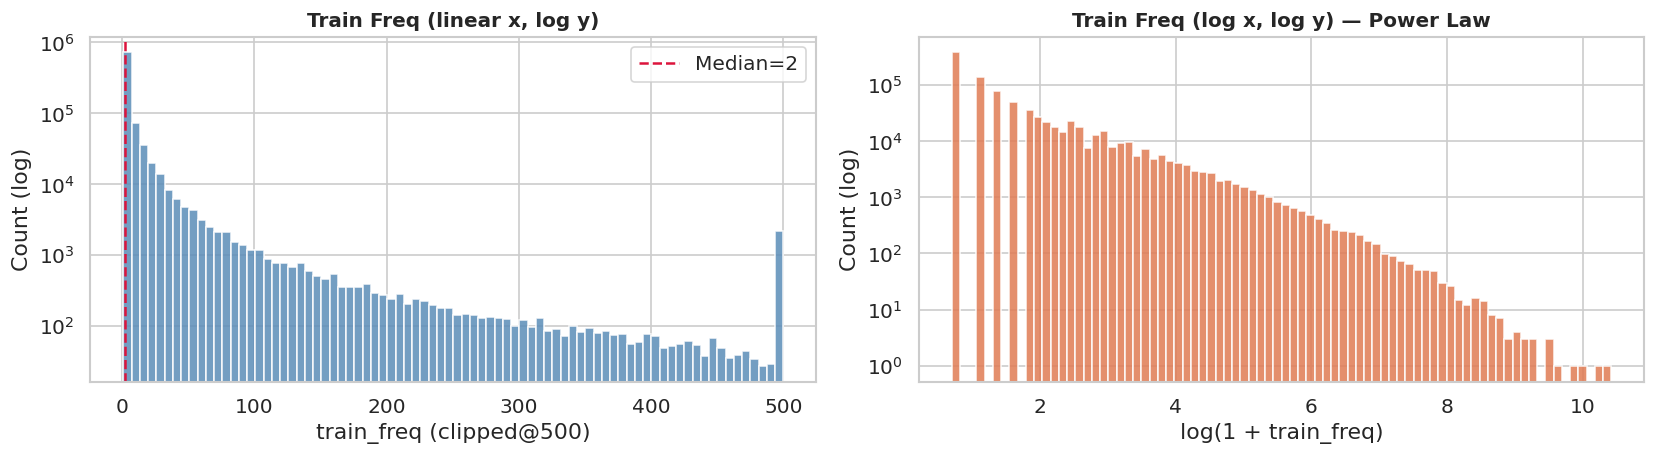

📊 Saved: eda_silver_train_freq.png


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — TRAIN_FREQ DISTRIBUTION (Power-Law)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 3 — TRAIN_FREQ DISTRIBUTION")
print("="*60)

freq_stats = con.execute("""
    SELECT
        MIN(train_freq) AS min_f, MEDIAN(train_freq) AS med_f,
        AVG(train_freq) AS avg_f, MAX(train_freq) AS max_f,
        SUM(CASE WHEN train_freq >= 5 THEN 1 ELSE 0 END)*100.0/COUNT(*) AS pct_gte5,
        SUM(CASE WHEN train_freq  = 1 THEN 1 ELSE 0 END)*100.0/COUNT(*) AS pct_eq1
    FROM item_popularity
""").df().iloc[0]
print(f"  Min={freq_stats['min_f']:.0f}  Median={freq_stats['med_f']:.0f}  "
      f"Mean={freq_stats['avg_f']:.2f}  Max={freq_stats['max_f']:.0f}")
print(f"  Items >= 5 lần : {freq_stats['pct_gte5']:.1f}%")
print(f"  Items = 1 lần  : {freq_stats['pct_eq1']:.1f}%")

freq_data     = con.execute("SELECT train_freq FROM item_popularity").df()["train_freq"]
freq_logp1    = np.log1p(freq_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(freq_data.clip(upper=500), bins=80, color="#5b8db8", log=True, edgecolor="white", alpha=0.85)
axes[0].axvline(freq_data.median(), color="crimson", linestyle="--", label=f"Median={freq_data.median():.0f}")
axes[0].set_title("Train Freq (linear x, log y)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("train_freq (clipped@500)"), axes[0].set_ylabel("Count (log)")
axes[0].legend()
axes[1].hist(freq_logp1, bins=80, color="#e07b54", log=True, edgecolor="white", alpha=0.85)
axes[1].set_title("Train Freq (log x, log y) — Power Law", fontsize=12, fontweight="bold")
axes[1].set_xlabel("log(1 + train_freq)"), axes[1].set_ylabel("Count (log)")
plt.tight_layout()
plt.savefig("eda_silver_train_freq.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_train_freq.png")


SECTION 4 — ITEM TEXT QUALITY (text_source_level & token_estimate)

[text_source_level]
  Level 4 (+Desc/Details):  1,610,012 (100.0%)

[token_estimate by popularity_group]
                  min_tok  med_tok  max_tok  pct_within_384
popularity_group                                           
HEAD                    7    197.0      486           100.0
MID                     1    182.0      369           100.0
TAIL                    1    162.0      516           100.0
COLD_START              1    165.0      607           100.0

  Items within max_length=384 tokens: 100.0%


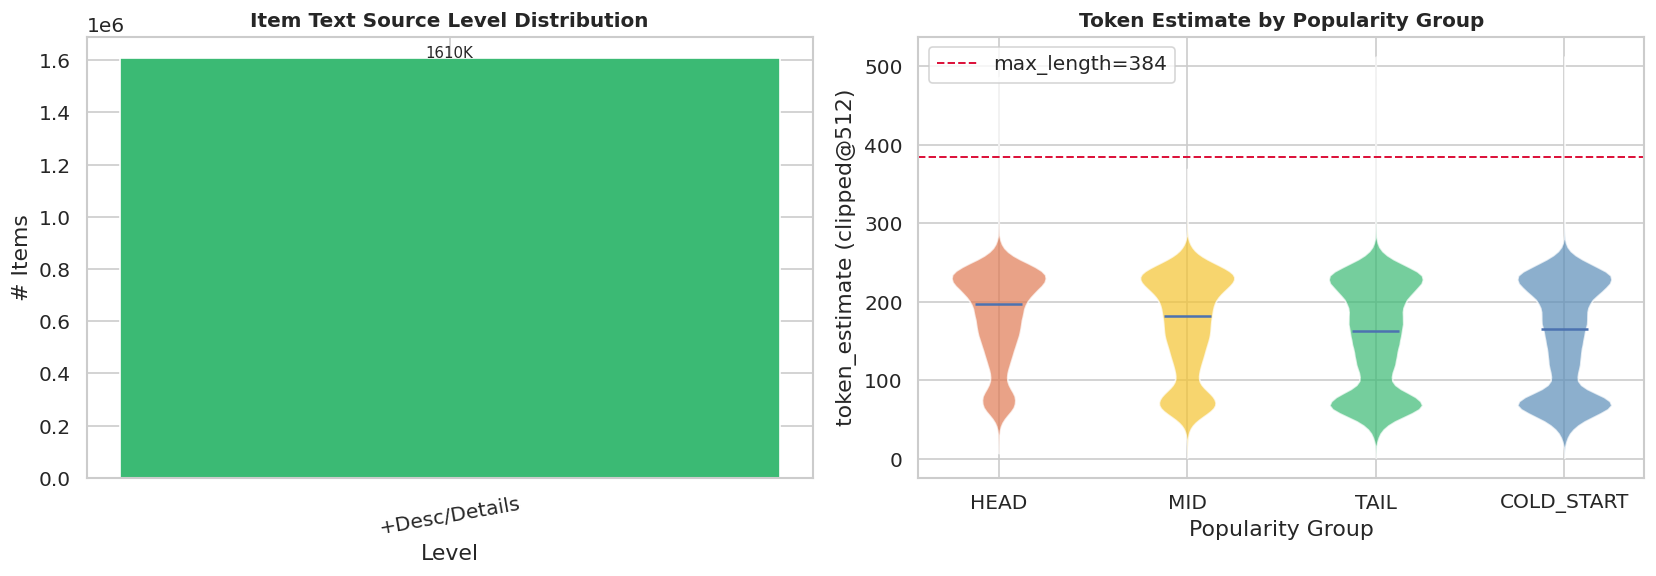

📊 Saved: eda_silver_item_text.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — ITEM TEXT QUALITY (text_source_level & token_estimate)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 4 — ITEM TEXT QUALITY (text_source_level & token_estimate)")
print("="*60)

LEVEL_LABELS = {1: "Title only", 2: "+Features", 3: "+Categories", 4: "+Desc/Details"}

lv_df = con.execute("""
    SELECT text_source_level, COUNT(*) AS cnt
    FROM item_text GROUP BY text_source_level ORDER BY text_source_level
""").df()
print("\n[text_source_level]")
for _, row in lv_df.iterrows():
    lv, cnt = int(row["text_source_level"]), int(row["cnt"])
    print(f"  Level {lv} ({LEVEL_LABELS.get(lv,'?')}): {cnt:>10,} ({cnt/n_all_total*100:.1f}%)")

tok_stats = con.execute("""
    SELECT popularity_group,
        MIN(token_estimate) AS min_tok, MEDIAN(token_estimate) AS med_tok,
        MAX(token_estimate) AS max_tok,
        AVG(CASE WHEN token_estimate <= 384 THEN 1.0 ELSE 0.0 END)*100 AS pct_within_384
    FROM item_text GROUP BY popularity_group
""").df().set_index("popularity_group").reindex(GROUP_ORDER)
print("\n[token_estimate by popularity_group]")
print(tok_stats.round(1).to_string())

within_384 = con.execute("""
    SELECT AVG(CASE WHEN token_estimate<=384 THEN 1.0 ELSE 0.0 END)*100 FROM item_text
""").df().iloc[0,0]
print(f"\n  Items within max_length=384 tokens: {within_384:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# text_source_level bar
ax = axes[0]
clr = [GROUP_COLORS["TAIL"], GROUP_COLORS["MID"], GROUP_COLORS["HEAD"], GROUP_COLORS["COLD_START"]]
bars = ax.bar([LEVEL_LABELS.get(int(r),f"L{r}") for r in lv_df["text_source_level"]],
              lv_df["cnt"], color=clr[:len(lv_df)], edgecolor="white")
for bar, val in zip(bars, lv_df["cnt"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f"{val/1e3:.0f}K", ha="center", fontsize=9)
ax.set_title("Item Text Source Level Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Level"), ax.set_ylabel("# Items"), ax.tick_params(axis='x', rotation=10)
# token_estimate violin
ax = axes[1]
groups_present = [g for g in GROUP_ORDER
                  if con.execute(f"SELECT COUNT(*) FROM item_text WHERE popularity_group='{g}'").df().iloc[0,0]>0]
vdata = [con.execute(
    f"SELECT LEAST(token_estimate,512) AS t FROM item_text WHERE popularity_group='{g}'"
).df()["t"] for g in groups_present]
parts = ax.violinplot(vdata, showmedians=True, showextrema=False)
for pc, g in zip(parts["bodies"], groups_present):
    pc.set_facecolor(GROUP_COLORS.get(g,"gray")); pc.set_alpha(0.7)
ax.set_xticks(range(1, len(groups_present)+1)); ax.set_xticklabels(groups_present)
ax.axhline(384, color="crimson", linestyle="--", linewidth=1.2, label="max_length=384")
ax.set_title("Token Estimate by Popularity Group", fontsize=12, fontweight="bold")
ax.set_xlabel("Popularity Group"), ax.set_ylabel("token_estimate (clipped@512)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_silver_item_text.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_item_text.png")


SECTION 5 — USER TEXT PROFILE
review_count_train: min=1  median=5  mean=7.50  max=938
Users với review_count >= 3  : 100.0%
Users [NO_TEXT] fallback     : 0
Global avg_rating            : 4.685


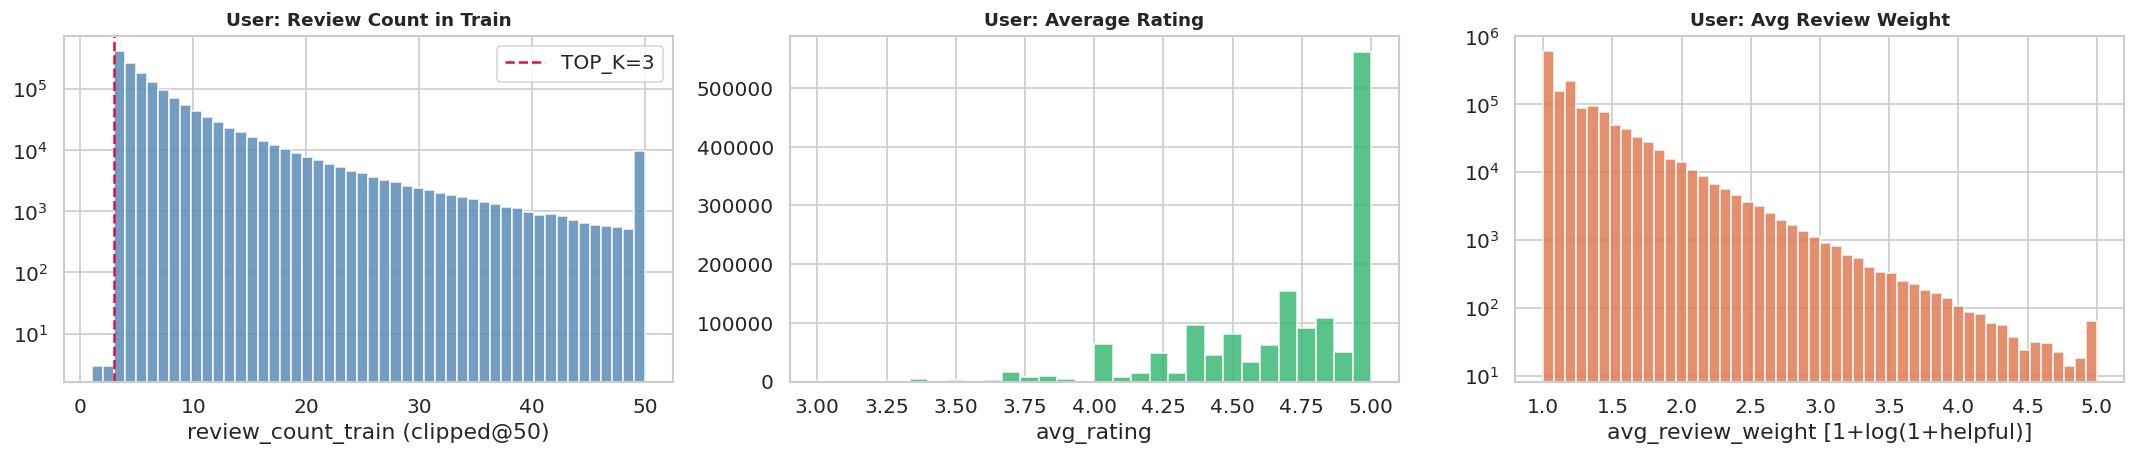

📊 Saved: eda_silver_user_profile.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — USER TEXT PROFILE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 5 — USER TEXT PROFILE")
print("="*60)

user_stats = con.execute("""
    SELECT
        MIN(review_count_train) AS min_rc, MEDIAN(review_count_train) AS med_rc,
        AVG(review_count_train) AS avg_rc, MAX(review_count_train) AS max_rc,
        SUM(CASE WHEN review_count_train >= 3 THEN 1 ELSE 0 END)*100.0/COUNT(*) AS pct_gte3,
        SUM(CASE WHEN user_text = '[NO_TEXT] User interaction profile' THEN 1 ELSE 0 END) AS n_no_text,
        AVG(avg_rating) AS global_avg_rating
    FROM user_text
""").df().iloc[0]
print(f"review_count_train: min={user_stats['min_rc']:.0f}  median={user_stats['med_rc']:.0f}  "
      f"mean={user_stats['avg_rc']:.2f}  max={user_stats['max_rc']:.0f}")
print(f"Users với review_count >= 3  : {user_stats['pct_gte3']:.1f}%")
print(f"Users [NO_TEXT] fallback     : {int(user_stats['n_no_text']):,}")
print(f"Global avg_rating            : {user_stats['global_avg_rating']:.3f}")

rc_data  = con.execute("SELECT LEAST(review_count_train,50) AS rc FROM user_text").df()["rc"]
ar_data  = con.execute("SELECT avg_rating FROM user_text").df()["avg_rating"]
arw_data = con.execute("SELECT LEAST(avg_review_weight,5) AS w FROM user_text").df()["w"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, data, color, xlabel, title in zip(axes,
    [rc_data, ar_data, arw_data],
    ["#5b8db8", "#3bba74", "#e07b54"],
    ["review_count_train (clipped@50)", "avg_rating", "avg_review_weight [1+log(1+helpful)]"],
    ["User: Review Count in Train", "User: Average Rating", "User: Avg Review Weight"]
):
    ax.hist(data, bins=50 if xlabel != "avg_rating" else 30,
            color=color, edgecolor="white", alpha=0.85, log=(xlabel!="avg_rating"))
    ax.set_xlabel(xlabel), ax.set_title(title, fontsize=11, fontweight="bold")
    if "count" in xlabel:
        ax.axvline(3, color="crimson", linestyle="--", label="TOP_K=3"); ax.legend()
plt.tight_layout()
plt.savefig("eda_silver_user_profile.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_user_profile.png")


SECTION 6 — RATING DISTRIBUTION IN SILVER TRAIN
✅ Positive-only confirmed: min rating = 3.0
 rating     cnt
    3.0  842702
    4.0 1851865
    5.0 8428858


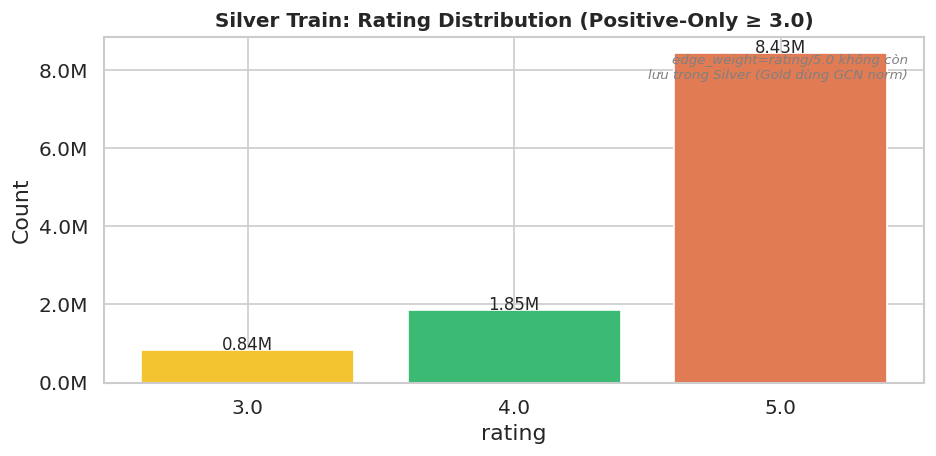

📊 Saved: eda_silver_rating.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — RATING DISTRIBUTION IN SILVER TRAIN (POSITIVE-ONLY CONFIRMED)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 6 — RATING DISTRIBUTION IN SILVER TRAIN")
print("="*60)

# Note: edge_weight đã bị comment ra (Gold chỉ dùng user_idx, item_idx)
# Kiểm tra rating thay vì edge_weight
rating_df = con.execute("""
    SELECT rating, COUNT(*) AS cnt
    FROM interactions_train
    GROUP BY rating ORDER BY rating
""").df()

min_rating = con.execute("SELECT MIN(rating) FROM interactions_train").df().iloc[0,0]
assert float(min_rating) >= 3.0, f"❌ rating < 3.0 tồn tại! min={min_rating}"
print(f"✅ Positive-only confirmed: min rating = {min_rating:.1f}")
print(rating_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    rating_df["rating"].astype(str), rating_df["cnt"],
    color=["#f4c430","#3bba74","#e07b54"][:len(rating_df)], edgecolor="white"
)
for bar, val in zip(bars, rating_df["cnt"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f"{val/1e6:.2f}M", ha="center", fontsize=10)
ax.set_xlabel("rating"), ax.set_ylabel("Count")
ax.set_title("Silver Train: Rating Distribution (Positive-Only ≥ 3.0)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
# Note về edge_weight
ax.text(0.98, 0.95, "edge_weight=rating/5.0 không còn\nlưu trong Silver (Gold dùng GCN norm)",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        color="gray", style="italic")
plt.tight_layout()
plt.savefig("eda_silver_rating.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_rating.png")


SECTION 7 — TEMPORAL INTERACTION PATTERN (year_month)
Time range: +31418-09 → 2023-09
Peak month: 2020-01 (146,450 interactions)


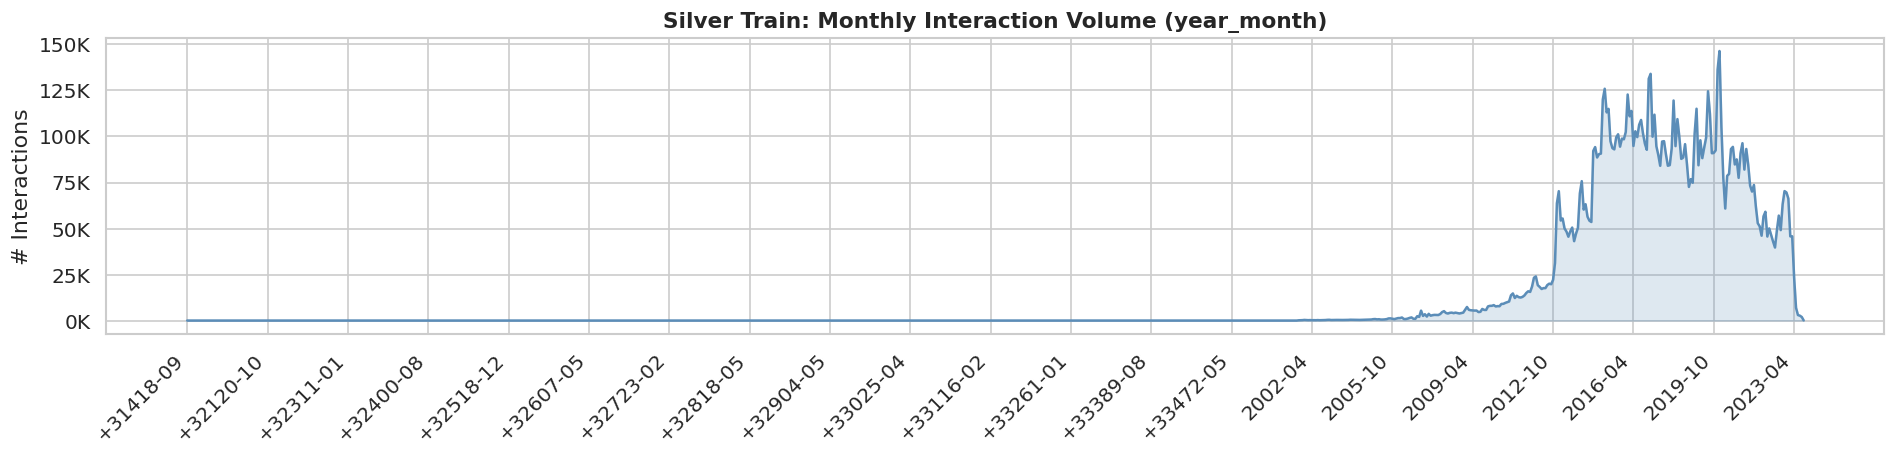

📊 Saved: eda_silver_temporal.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — TEMPORAL (year_month)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 7 — TEMPORAL INTERACTION PATTERN (year_month)")
print("="*60)

monthly = con.execute("""
    SELECT year_month, COUNT(*) AS cnt
    FROM interactions_train
    GROUP BY year_month ORDER BY year_month
""").df()
print(f"Time range: {monthly['year_month'].min()} → {monthly['year_month'].max()}")
peak = monthly.loc[monthly["cnt"].idxmax()]
print(f"Peak month: {peak['year_month']} ({peak['cnt']:,} interactions)")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(range(len(monthly)), monthly["cnt"], color="#5b8db8", linewidth=1.5)
ax.fill_between(range(len(monthly)), monthly["cnt"], alpha=0.2, color="#5b8db8")
tick_step = max(1, len(monthly)//20)
ax.set_xticks(range(0, len(monthly), tick_step))
ax.set_xticklabels(monthly["year_month"].iloc[::tick_step], rotation=45, ha="right")
ax.set_title("Silver Train: Monthly Interaction Volume (year_month)", fontsize=13, fontweight="bold")
ax.set_ylabel("# Interactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig("eda_silver_temporal.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_temporal.png")



SECTION 8 — VAL GROUND TRUTH ANALYSIS
Total val interactions       : 1,483,920
HEAD items                   : 1,220,822 (82.3%)
MID  items                   : 64,464 (4.3%)
TAIL items (is_tail=1)        : 134,008 (9.0%)
COLD-START (is_cold_start=1)  : 64,626 (4.4%)


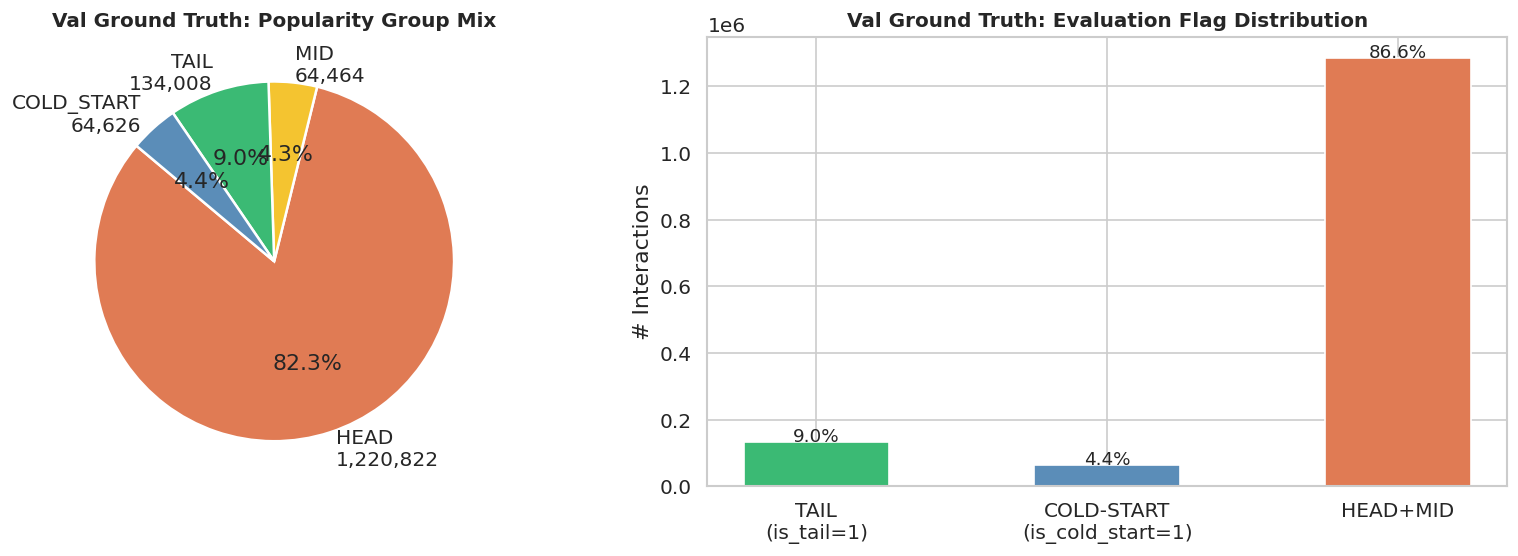

📊 Saved: eda_silver_val_ground_truth.png


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — VAL GROUND TRUTH: is_tail / is_cold_start
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 8 — VAL GROUND TRUTH ANALYSIS")
print("="*60)

vgt = con.execute("""
    SELECT
        COUNT(*)                     AS total,
        SUM(is_tail)                 AS n_tail,
        SUM(is_cold_start)           AS n_cold,
        SUM(CASE WHEN popularity_group='HEAD' THEN 1 ELSE 0 END) AS n_head,
        SUM(CASE WHEN popularity_group='MID'  THEN 1 ELSE 0 END) AS n_mid
    FROM val_ground_truth
""").df().iloc[0]

n_total = int(vgt["total"])
print(f"Total val interactions       : {n_total:,}")
print(f"HEAD items                   : {int(vgt['n_head']):,} ({int(vgt['n_head'])/n_total*100:.1f}%)")
print(f"MID  items                   : {int(vgt['n_mid']):,} ({int(vgt['n_mid'])/n_total*100:.1f}%)")
print(f"TAIL items (is_tail=1)        : {int(vgt['n_tail']):,} ({int(vgt['n_tail'])/n_total*100:.1f}%)")
print(f"COLD-START (is_cold_start=1)  : {int(vgt['n_cold']):,} ({int(vgt['n_cold'])/n_total*100:.1f}%)")

pop_val = con.execute("""
    SELECT popularity_group, COUNT(*) AS cnt
    FROM val_ground_truth GROUP BY popularity_group
""").df().set_index("popularity_group")["cnt"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
data   = [pop_val.get(g, 0) for g in GROUP_ORDER]
labels = [f"{g}\n{v:,}" for g, v in zip(GROUP_ORDER, data)]
colors = [GROUP_COLORS[g] for g in GROUP_ORDER]
ax.pie(data, labels=labels, colors=colors, autopct="%1.1f%%",
       startangle=140, wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax.set_title("Val Ground Truth: Popularity Group Mix", fontsize=12, fontweight="bold")

ax = axes[1]
flag_data   = {"TAIL\n(is_tail=1)": int(vgt['n_tail']),
               "COLD-START\n(is_cold_start=1)": int(vgt['n_cold']),
               "HEAD+MID": int(vgt['n_head'])+int(vgt['n_mid'])}
flag_colors = [GROUP_COLORS["TAIL"], GROUP_COLORS["COLD_START"], GROUP_COLORS["HEAD"]]
bars = ax.bar(flag_data.keys(), flag_data.values(), color=flag_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, flag_data.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f"{val/n_total*100:.1f}%", ha="center", fontsize=11)
ax.set_title("Val Ground Truth: Evaluation Flag Distribution", fontsize=12, fontweight="bold")
ax.set_ylabel("# Interactions")
plt.tight_layout()
plt.savefig("eda_silver_val_ground_truth.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_silver_val_ground_truth.png")

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — TRAIN vs VAL OVERLAP
# Tối ưu RAM: dùng EXISTS (semi-join) thay cross join; 1 GROUP BY pivot thay
# 8 queries riêng lẻ. DuckDB xử lý hoàn toàn trong engine, không kéo data về Python.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 9 — TRAIN vs VAL OVERLAP ANALYSIS")
print("="*60)

# ── Query 1: user & item overlap — EXISTS (semi-join), không dùng cross join ──
overlap = con.execute("""
    SELECT
        -- % users trong val cũng có trong train
        SUM(CASE WHEN EXISTS (
            SELECT 1 FROM interactions_train t
            WHERE t.reviewer_id = v.reviewer_id
        ) THEN 1 ELSE 0 END) * 100.0 / COUNT(DISTINCT v.reviewer_id) AS user_overlap_pct,

        -- % items trong val cũng có trong train
        SUM(CASE WHEN EXISTS (
            SELECT 1 FROM interactions_train t
            WHERE t.parent_asin = v.parent_asin
        ) THEN 1 ELSE 0 END) * 100.0 / COUNT(DISTINCT v.parent_asin) AS item_overlap_pct

    FROM (SELECT DISTINCT reviewer_id, parent_asin FROM interactions_val) v
""").df().iloc[0]

user_ov = float(overlap["user_overlap_pct"])
item_ov = float(overlap["item_overlap_pct"])

print(f"Users in val also in train  : {user_ov:.1f}% (phải ~100% — leave-one-out)")
print(f"Items in val also in train  : {item_ov:.1f}%")
print(f"Cold-start items in val     : {100-item_ov:.1f}%")

# ── Query 2: popularity group counts — 1 GROUP BY pivot, không lặp 4 queries ──
pop_split = con.execute("""
    SELECT
        popularity_group,
        SUM(CASE WHEN src='train' THEN 1 ELSE 0 END) AS cnt_train,
        SUM(CASE WHEN src='val'   THEN 1 ELSE 0 END) AS cnt_val
    FROM (
        SELECT popularity_group, 'train' AS src FROM interactions_train
        UNION ALL
        SELECT popularity_group, 'val'   AS src FROM interactions_val
    )
    GROUP BY popularity_group
""").df().set_index("popularity_group")

print("\n[Popularity Group by Split]")
for g in GROUP_ORDER:
    ct = int(pop_split.loc[g, "cnt_train"]) if g in pop_split.index else 0
    cv = int(pop_split.loc[g, "cnt_val"])   if g in pop_split.index else 0
    print(f"  {g:<12}: train={ct:>10,} | val={cv:>8,}")



SECTION 9 — TRAIN vs VAL OVERLAP ANALYSIS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Users in val also in train  : 100.0% (phải ~100% — leave-one-out)
Items in val also in train  : 412.9%
Cold-start items in val     : -312.9%

[Popularity Group by Split]
  HEAD        : train= 9,548,132 | val=1,220,822
  MID         : train=   490,490 | val=  64,464
  TAIL        : train= 1,084,803 | val= 134,008
  COLD_START  : train=         0 | val=  64,626


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — TỔNG KẾT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TỔNG KẾT SILVER EDA")
print("="*60)

n_train = con.execute("SELECT COUNT(*) FROM interactions_train").df().iloc[0,0]
n_val   = con.execute("SELECT COUNT(*) FROM interactions_val").df().iloc[0,0]

summary = {
    "n_items_popularity"      : int(n_train_total),
    "n_items_text_profile"    : int(n_all_total),
    "n_users_text_profile"    : con.execute("SELECT COUNT(*) FROM user_text").df().iloc[0,0],
    "n_edges_train"           : int(n_train),
    "n_edges_val"             : int(n_val),
    "n_val_ground_truth"      : n_total,
    "n_HEAD_%"                : f"{pop_train.get('HEAD',0)/max(n_train_total,1)*100:.1f}%",
    "n_MID_%"                 : f"{pop_train.get('MID',0)/max(n_train_total,1)*100:.1f}%",
    "n_TAIL_%"                : f"{pop_train.get('TAIL',0)/max(n_train_total,1)*100:.1f}%",
    "n_COLD_in_text_%"        : f"{pop_all.get('COLD_START',0)/max(n_all_total,1)*100:.1f}%",
    "edge_weight"             : "❌ Đã comment — Gold dùng GCN normalization (D^{-1/2})",
    "rating_min_silver"       : float(min_rating),
    "val_tail_%"              : f"{int(vgt['n_tail'])/n_total*100:.1f}%",
    "val_cold_start_%"        : f"{int(vgt['n_cold'])/n_total*100:.1f}%",
    "items_within_384_tok_%"  : f"{within_384:.1f}%",
    "user_overlap_val_%"      : round(float(user_ov), 1),
    "item_overlap_val_%"      : round(float(item_ov), 1),
}
for k, v in summary.items():
    print(f"  {k:<35} : {v}")

con.close()
print("\n✅ Silver EDA hoàn tất!")


TỔNG KẾT SILVER EDA
  n_items_popularity                  : 922459
  n_items_text_profile                : 1610012
  n_users_text_profile                : 1483919
  n_edges_train                       : 11123425
  n_edges_val                         : 1483920
  n_val_ground_truth                  : 1483920
  n_HEAD_%                            : 21.0%
  n_MID_%                             : 9.1%
  n_TAIL_%                            : 69.8%
  n_COLD_in_text_%                    : 42.7%
  edge_weight                         : ❌ Đã comment — Gold dùng GCN normalization (D^{-1/2})
  rating_min_silver                   : 3.0
  val_tail_%                          : 9.0%
  val_cold_start_%                    : 4.4%
  items_within_384_tok_%              : 100.0%
  user_overlap_val_%                  : 100.0
  item_overlap_val_%                  : 412.9

✅ Silver EDA hoàn tất!
